In [16]:
import pandas as pd

def get_current_bonds(file_iter, N_patches, pairs=False):
    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
    clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,5,6], names=['id', 'patch_coord', 'patch_cluster'])
    bonded_clusters = clusters.loc[clusters['patch_coord'] > 0].copy() # filter only consider bonds with at least 1 patch (patch_coord is in column 5)
    bonded_clusters.sort_values(by='patch_cluster', inplace=True) # sort by patch_cluster (get bonded pairs) (patch_cluster is in column 6)
    bonded_clusters.reset_index(drop=True, inplace=True)

    arr = bonded_clusters.to_numpy()

    for i in range(len(arr)-1):
        id1, id2 = int(arr[i, 0]), int(arr[i+1, 0]) # get ids of current and next cluster
        if int(arr[i, 2]) == int(arr[i+1, 2]): # if same patch_cluster, they are bonded
            if pairs:
                ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                current_bonds.add(ids) # add to current bonds set
            else:
                current_bonds.add(id1) # add to current bonds set
                current_bonds.add(id2) # add to current bonds set
    
    return current_bonds

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_431235/3143257974.py:5: SyntaxWarning: invalid escape sequence '\s'
  clusters = pd.read_csv(file_iter, delimiter='\s+', header=None, nrows=N_patches, usecols=[0,5,6], names=['id', 'patch_coord', 'patch_cluster'])


## Lifetime algorithm with different $r_{\text{on}}, r_{\text{off}}$

With different radii for forming/breaking a bond, we should avoid jitter close to one cutoff that result in tiny lifetimes. This does require generating and reading two clustering dumps, but we can dump both in one file so we at least won't have too many files.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_buffered_lifetimes(filename_on, filename_off, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}

    N_patches = 0
    time = 0
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_on, N_patches, pairs=True)
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_off, N_patches, pairs=True)

                    broken_bonds = bonded_pairs.keys() - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                        lifetime = time - start_time
                        if (lifetime > timestep):
                            bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
    return bond_lifetimes



## Offtime algorithm with different $r_{\text{on}}, r_{\text{off}}$

With different radii for forming/breaking a bond, we should avoid jitter close to one cutoff that result in tiny lifetimes. This does require generating and reading two clustering dumps, but we can dump both in one file so we at least won't have too many files.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

pd.options.mode.chained_assignment = None  # default='warn'

"""
Process offtimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The unbonded_patches list is a dictionary where the key is a patch's id and the value is the last timestep when a bond it was part of breaks.

The bond_offtimes list is a list of tuples (id, start_time, end_time, offtime) for each bonded pair that has formed.

If there are any bonded_pairs that have not created by the end of the dump, we ignore them and do not record a offtime for them.

At the start of the simulation, all patches are unbonded, so we do not start any timers for them. Therefore, it takes at least one creation and breaking event 
for bond offtimes to start being recorded, might take some time to get to a steady state.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename_on: path to the clustering data file (for creating bonds)
    - filename_off: path to the clustering data file (for breaking bonds)
    - timestep: timestep size in LJ units (default is 0.002)
Returns:
    - bond_offtimes: list of tuples (id, start_time, end_time, offtime) for each patch
"""
def process_buffered_offtimes(filename_on, filename_off, timestep=0.002):
    # init empty bond offtime list
    bond_offtimes = []
    # init empty bonded pair dict. lookup by id. value is end_time of the previous bond patch was part of.
    unbonded_ids = {}

    all_ids = set()
    N_patches = 0
    time = 0
    with open(filename_on, 'r') as f_on:
        while True:
            line = f_on.readline()
            if not line:
                break
            if line.startswith("ITEM: TIMESTEP"):
                time = float(f_on.readline().strip()) * timestep
            elif line.startswith("ITEM: NUMBER OF ATOMS") and len(all_ids) == 0:
                N_patches = int(f_on.readline())
                print(f"Number of patches: {N_patches}")
            elif line.startswith("ITEM: ATOMS") and len(all_ids) == 0:
                # read next N_patches rows using pandas (fast C engine), only first column
                ids_df = pd.read_csv(f_on, sep=r'\s+', header=None, nrows=N_patches, usecols=[0], engine='c')
                all_ids.update(ids_df.iloc[:,0].astype(int).tolist())
                print(f"Read {len(all_ids)} patch ids from {filename_on}")
                # break
    total_time = time

    # print(f"Total number of patches: {len(all_ids)}")
    # print(f"Total time: {total_time:.3f} (LJ units)")

    # pbar = tqdm(total=total_time, desc="Processing bond offtimes")

    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off: 
            time = 0
            prev_time = 0
            while True:
                # stop reading BOTH if either file is done

                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    prev_time = time
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_on, N_patches)

                    # print(f"Current bonds: {len(current_bonds)}")
                    for id in current_bonds:
                        if id in unbonded_ids: # if just formed, stop their timers
                            start_time = unbonded_ids.pop(id)
                            bond_offtimes.append((id, start_time, time, time - start_time))
                    del current_bonds # free memory

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = get_current_bonds(f_off, N_patches)

                    broken_bonds = all_ids.difference(unbonded_ids, current_bonds) # bonds that are in unbonded_ids but not in current_bonds are broken
                    for id in broken_bonds: # just broken, set start of offtime and track timers
                        unbonded_ids[int(id)] = time
                    del broken_bonds # free memory
                    del current_bonds # free memory

                    # pbar.update(time - prev_time)
                
    return bond_offtimes



## Generating life/offtime series

In [19]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

def process_and_save_lifetimes(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    lifetimes = process_buffered_lifetimes(filename_on, filename_off)
    lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    lifetimes_df.to_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
# finish = Parallel(n_jobs=6)(delayed(process_and_save_lifetimes)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on <= cutoff_off for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


In [20]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [90, 100, 110, 120, 130]

def process_and_save_offtimes(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    offtimes = process_buffered_offtimes(filename_on, filename_off)
    offtimes_df = pd.DataFrame(offtimes, columns=["id", "start_time", "end_time", "offtime"])
    offtimes_df.to_csv(f"data/offtimes/buffered_offtimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed offtimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total offtimes recorded: {len(offtimes)} in {time() - start:.2f} seconds")

# process_and_save_offtimes(0.7, 0.7, 100)

# only process offtimes for cutoff_on < cutoff_off to avoid duplicates
# finish = Parallel(n_jobs=5)(delayed(process_and_save_offtimes)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on <= cutoff_off for A in As)



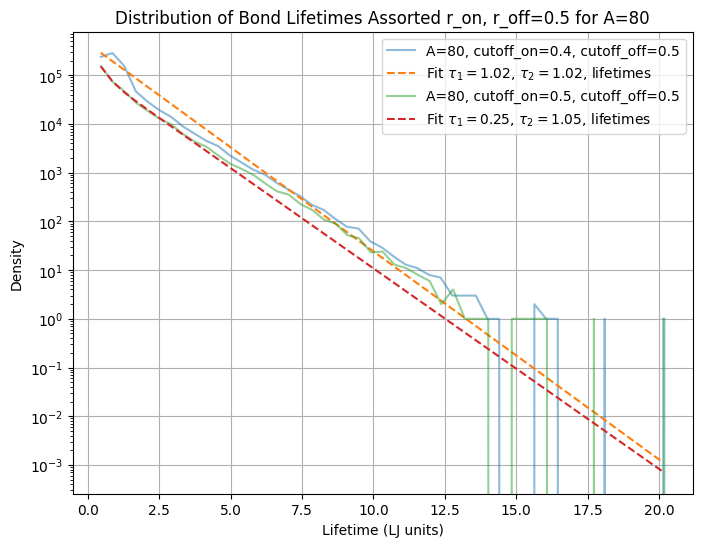

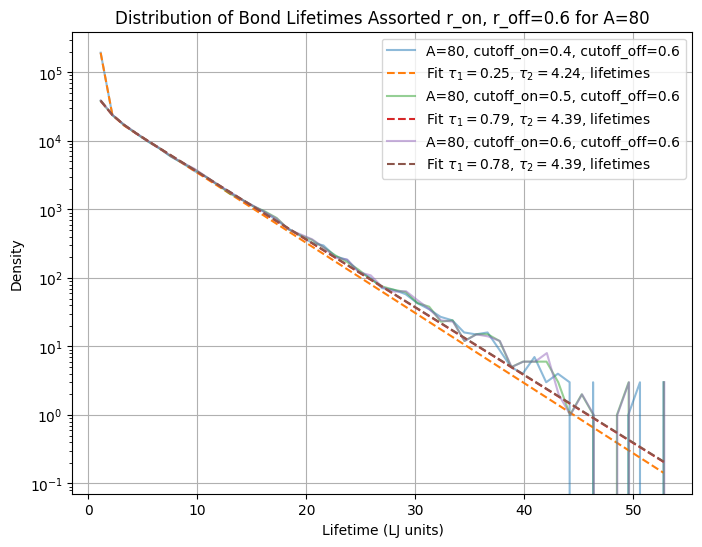

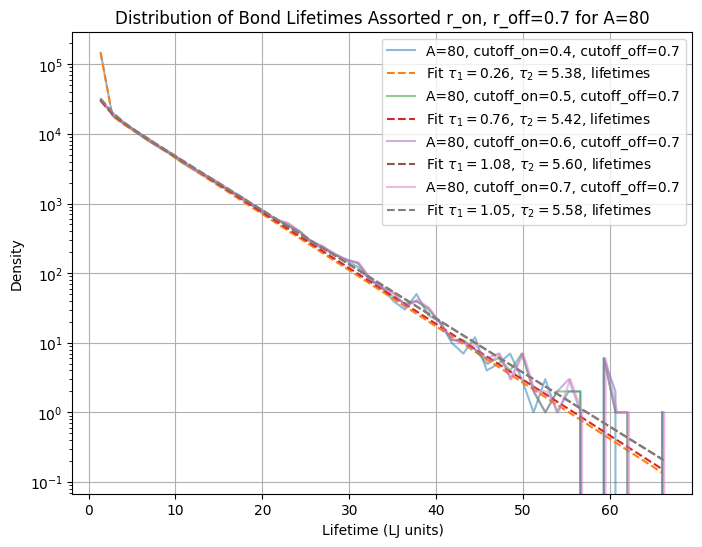

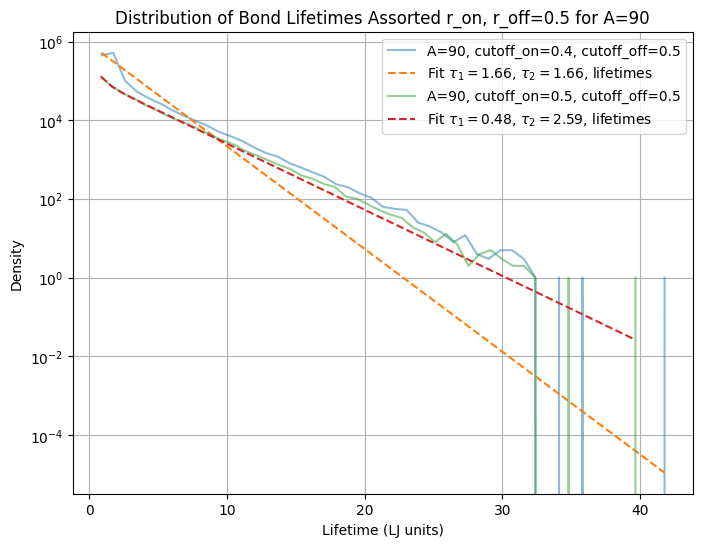

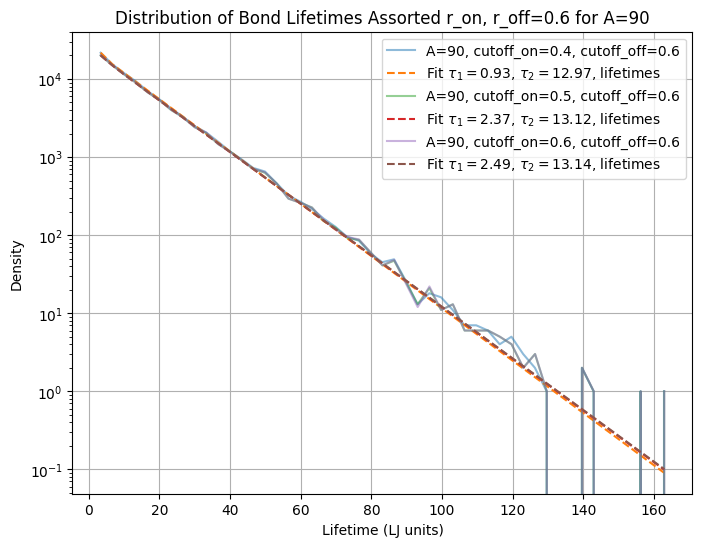

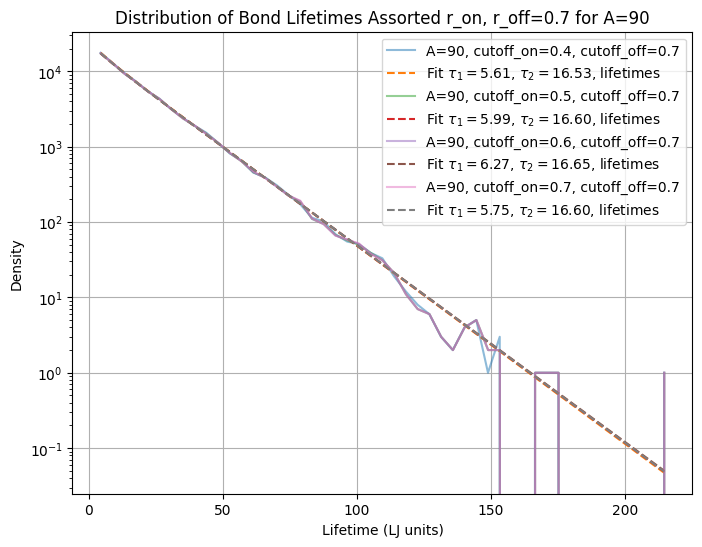

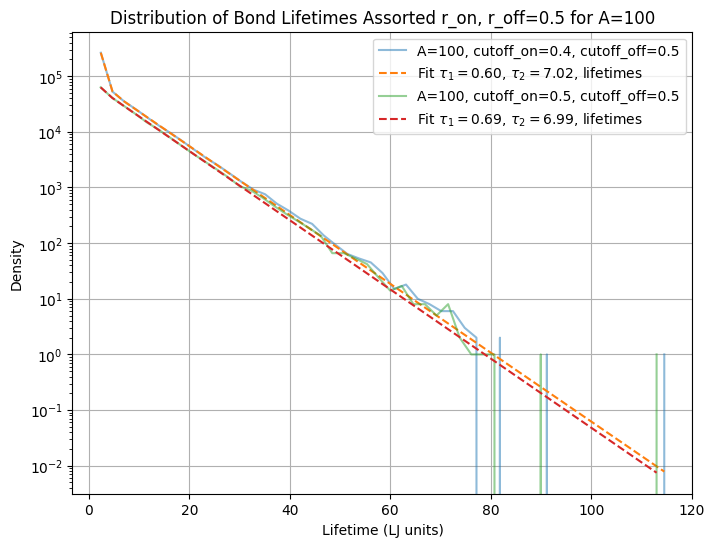

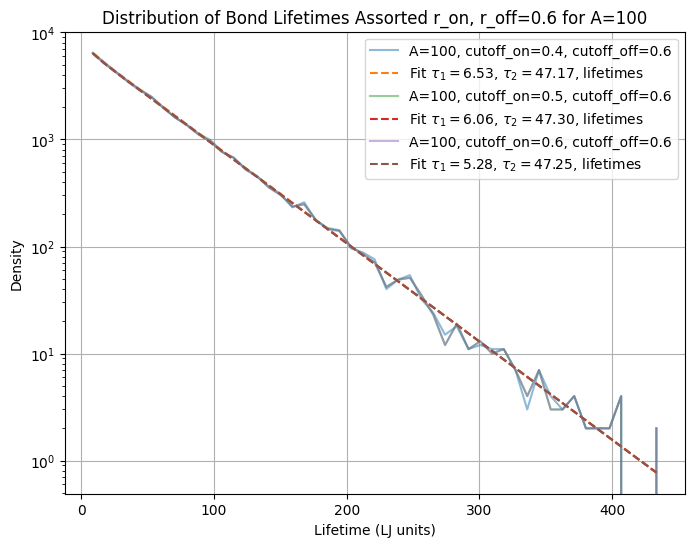

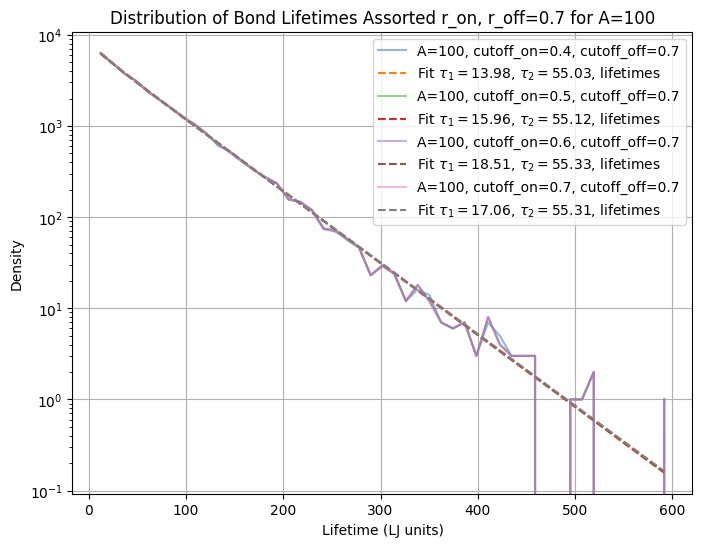

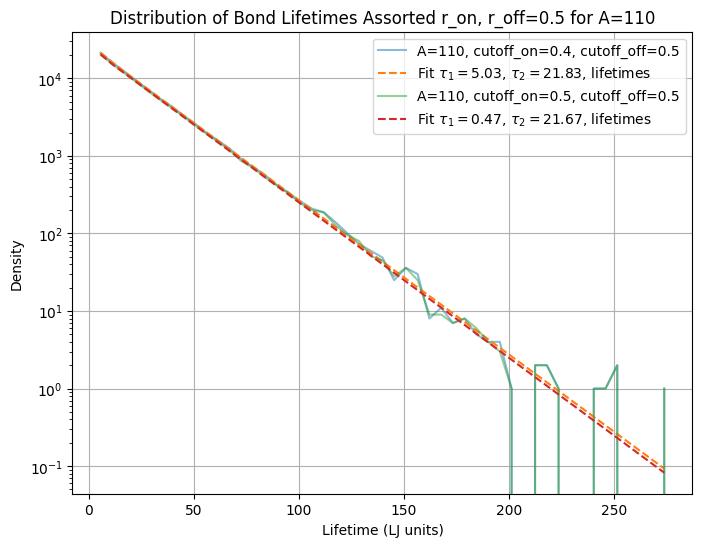

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


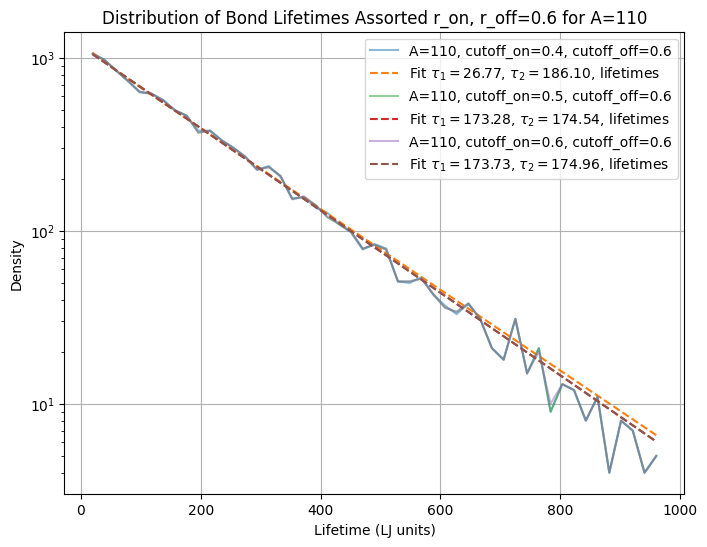

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


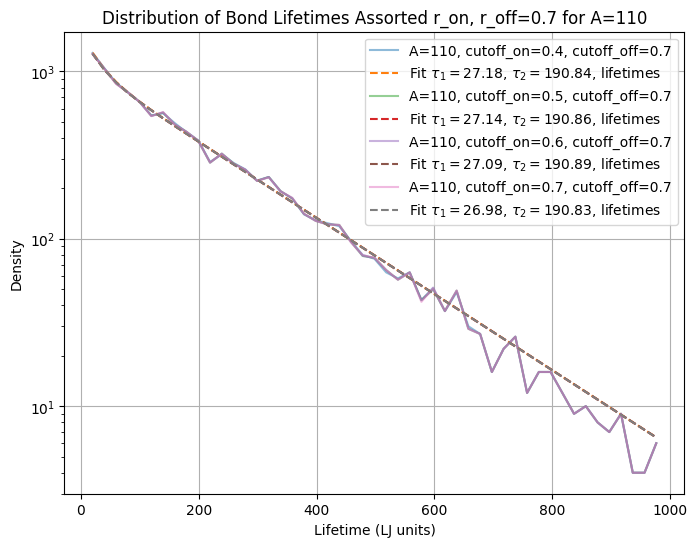

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in add
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


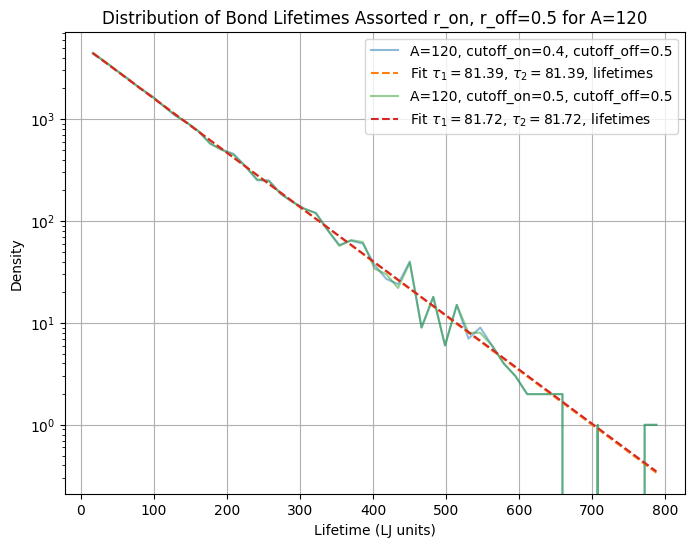

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


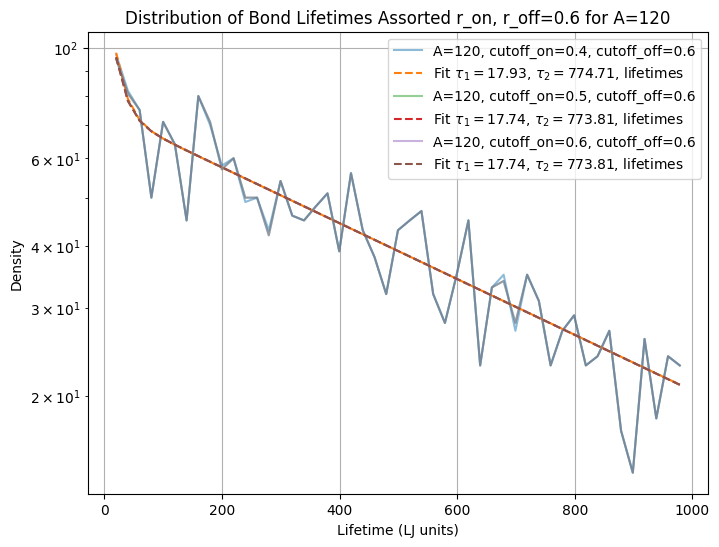

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


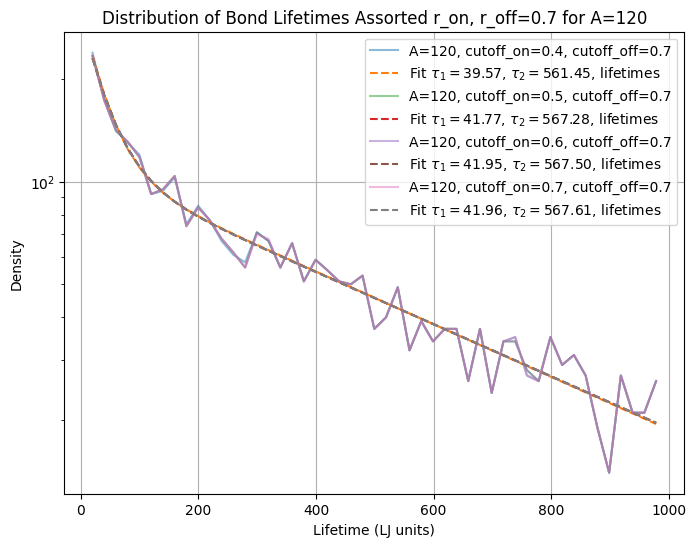

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


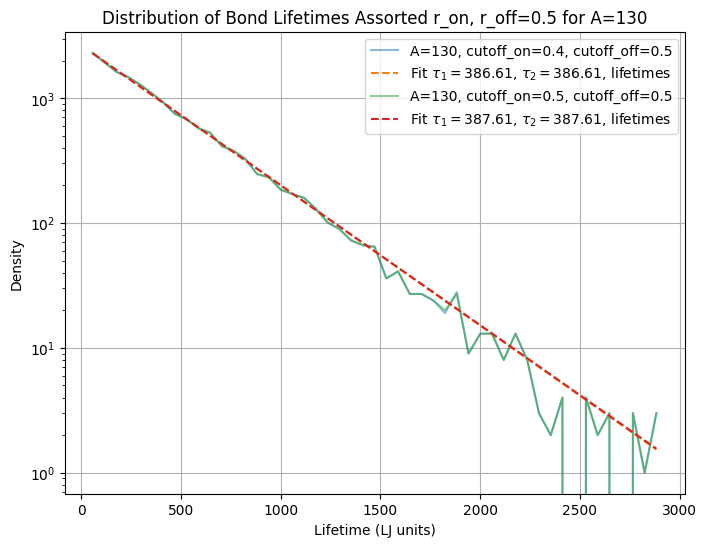

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


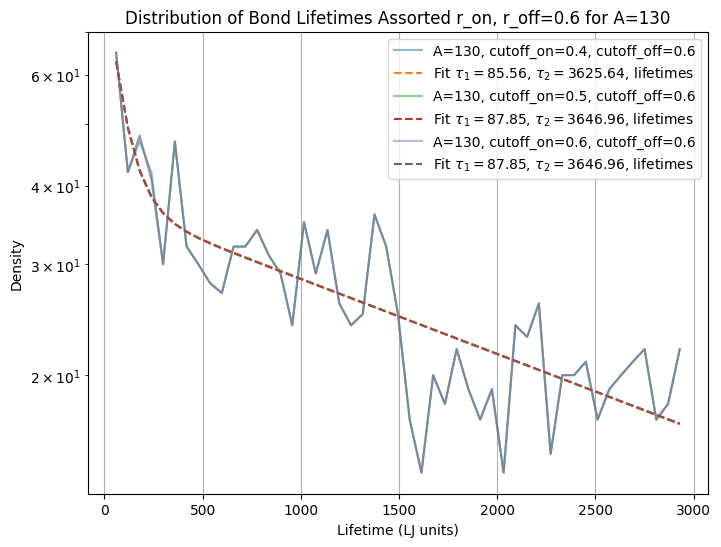

/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2820276420.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


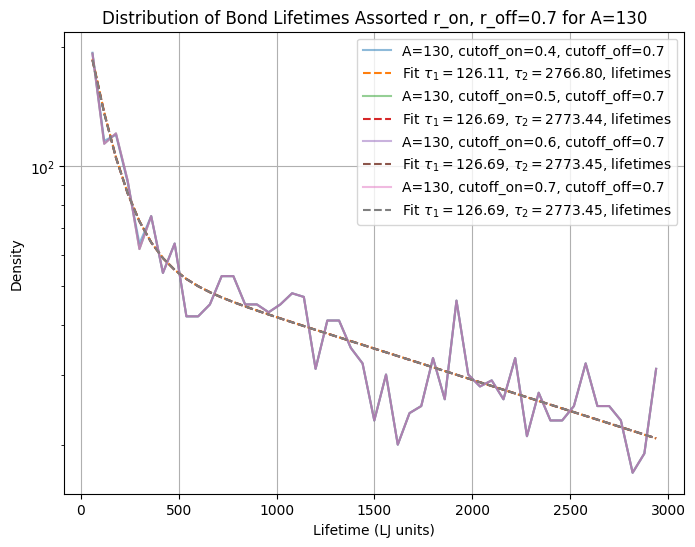

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def biexponential(x, a1, b1, a2, b2):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)

def single_exponential(x, a, b):
    return a * np.exp(-b * x)

tau_list = []

As = [80, 90, 100, 110, 120, 130]
cutoff_on_list = [0.4, 0.5, 0.6, 0.7]
cutoff_off_list = [0.5, 0.6, 0.7]

for A in As:
    for cutoff_off in cutoff_off_list:
        fig = plt.figure(figsize=(8, 6))
        for cutoff_on in cutoff_on_list:
            if cutoff_on <= cutoff_off:
            
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)
                # print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                # print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=100000000)
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                # print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                tau_list.append([A, "life", cutoff_on, cutoff_off, tau_1, tau_2])

                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}, lifetimes")
                
        plt.xlabel("Lifetime (LJ units)")
        plt.ylabel("Density")
        plt.yscale("log")
        # plt.ylim(0, 0.2)
        plt.grid()
        plt.title(f"Distribution of Bond Lifetimes Assorted r_on, r_off={cutoff_off} for A={A}")
        plt.legend()
        plt.show()


df = pd.DataFrame(tau_list, columns=["A", "off/life", "cutoff_on", "cutoff_off", "tau_1", "tau_2"])
df.to_csv("data/lifetimes/tau_lifetimes.csv", index=False)

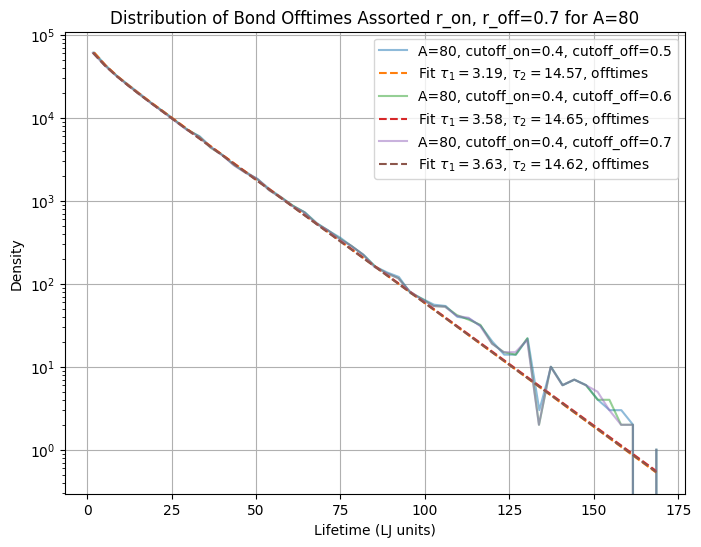

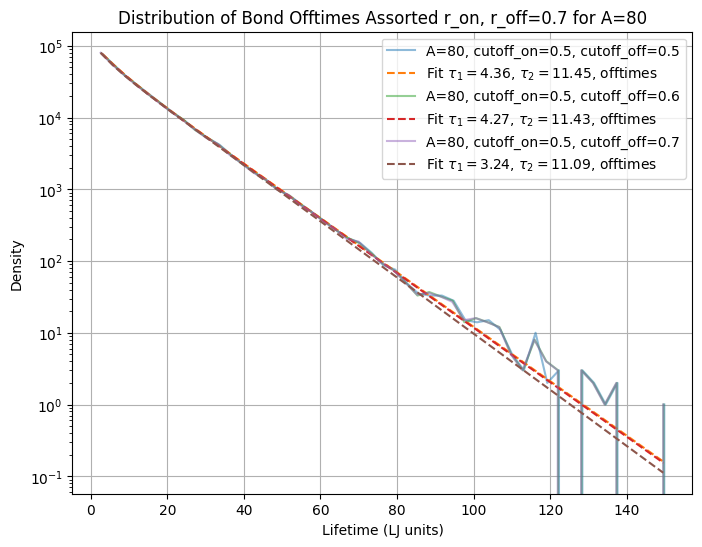

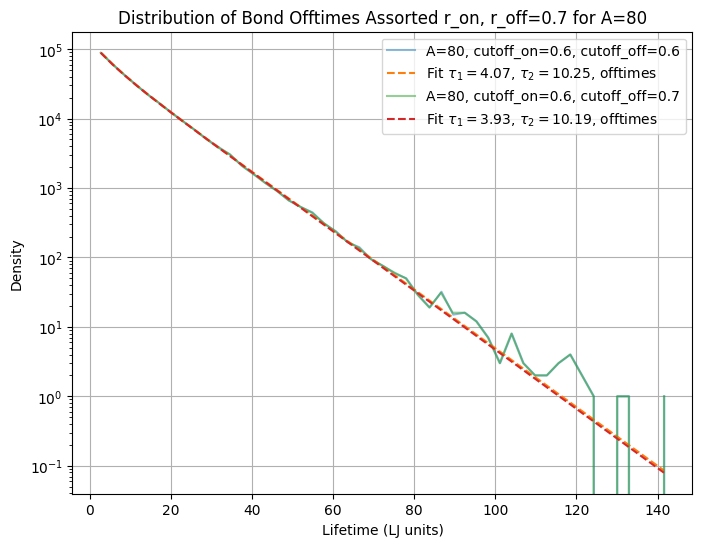

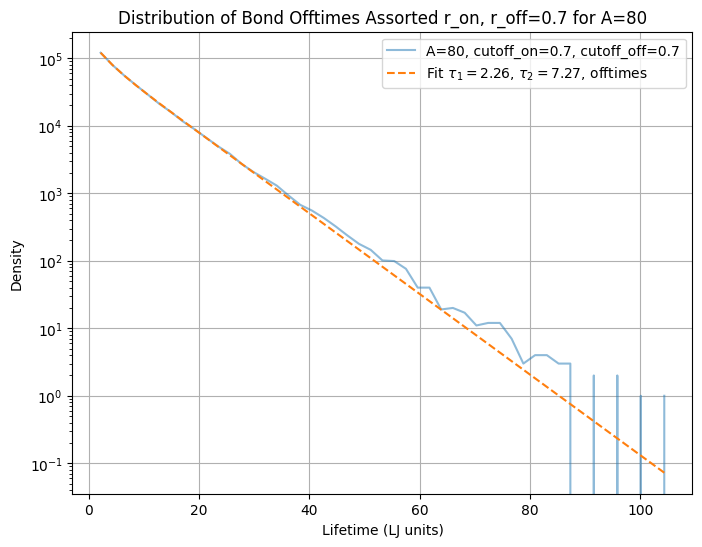

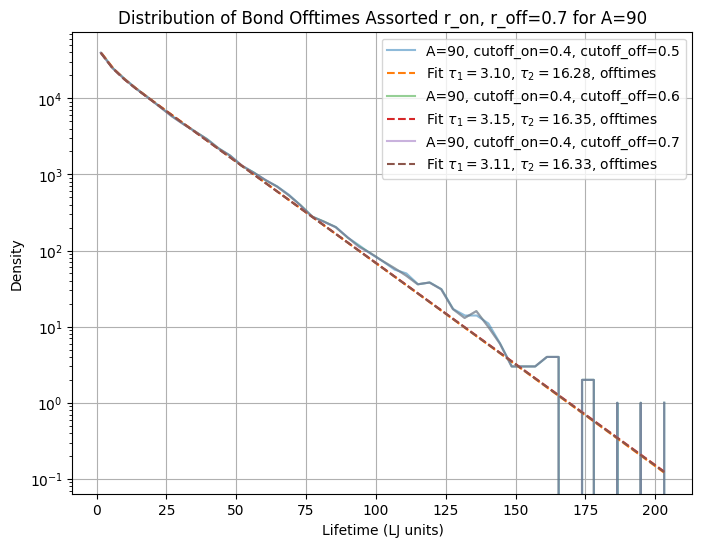

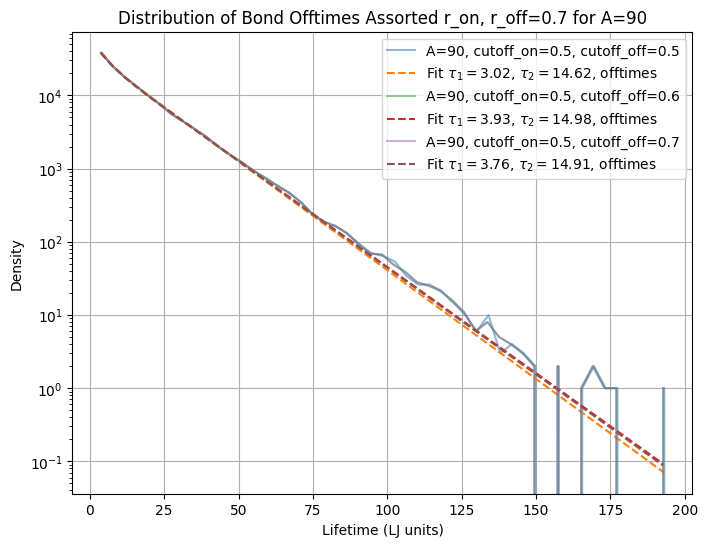

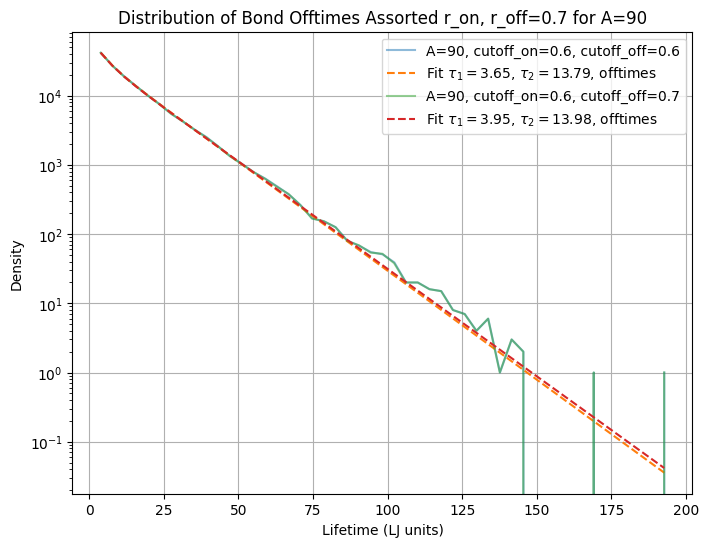

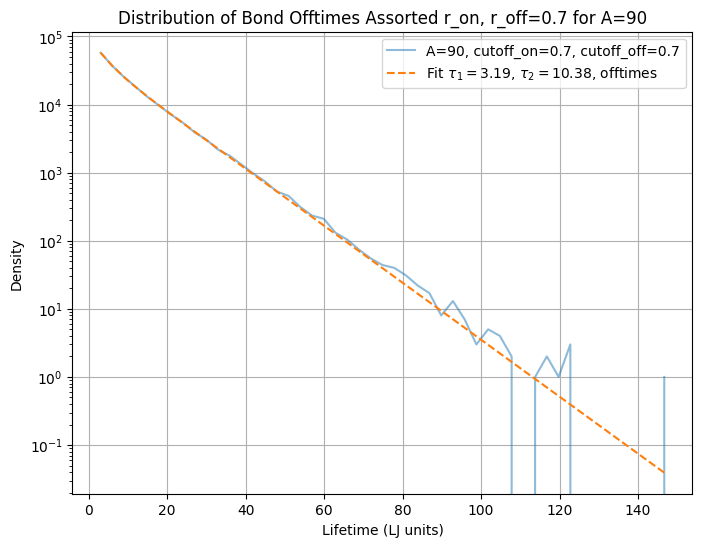

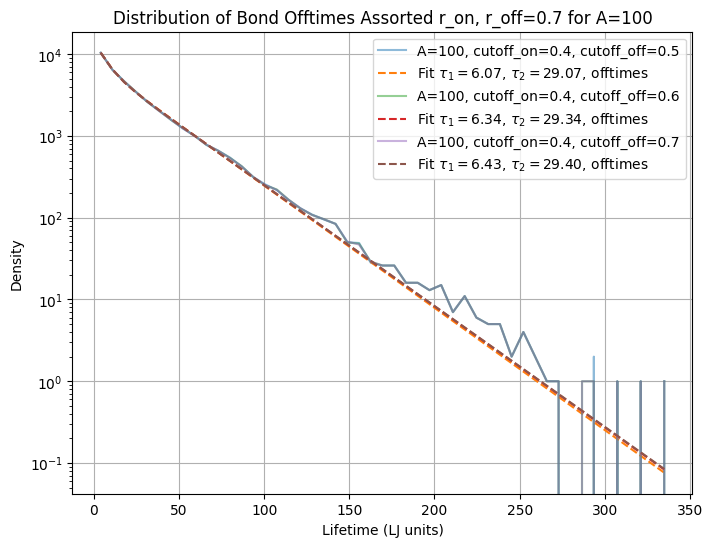

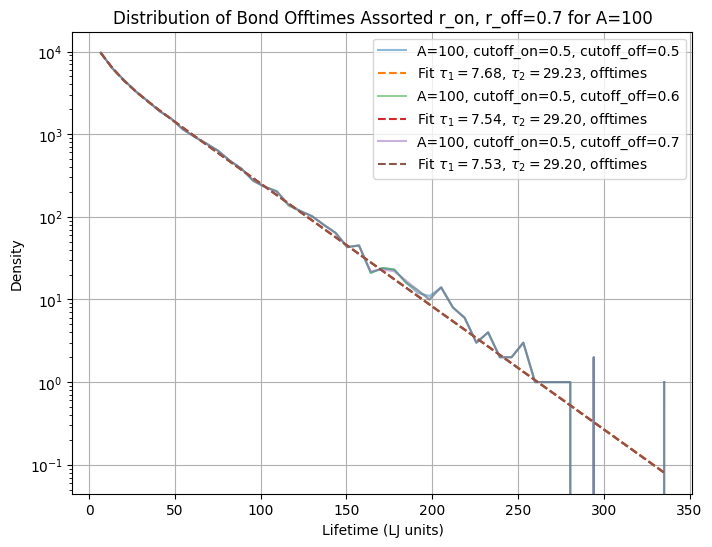

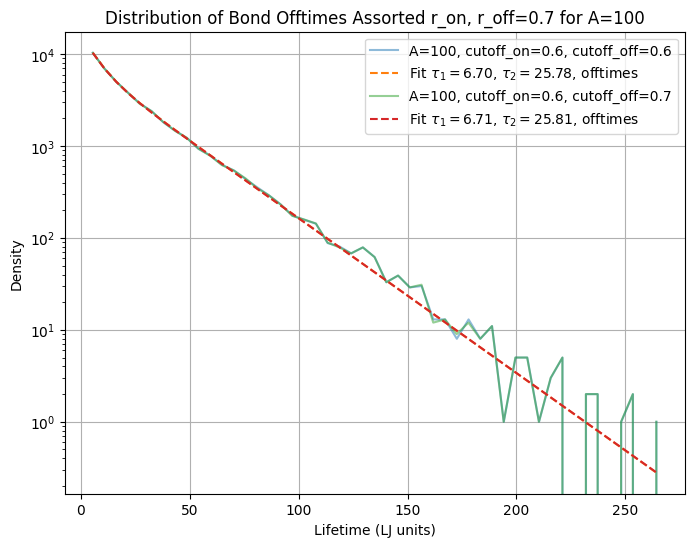

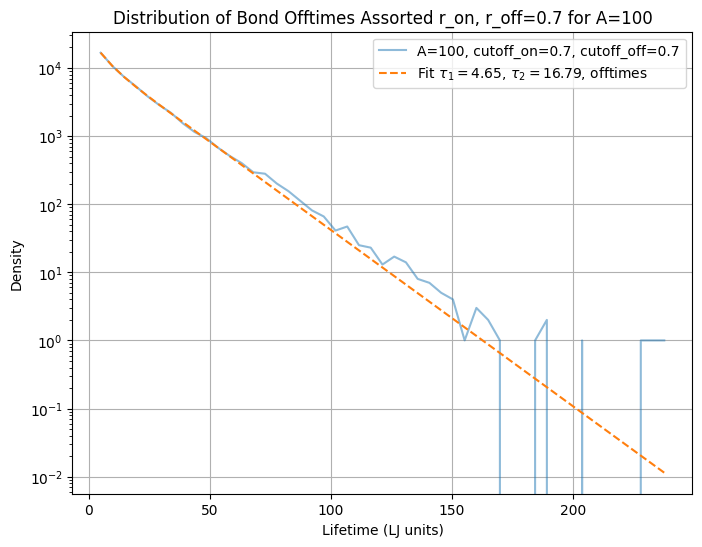

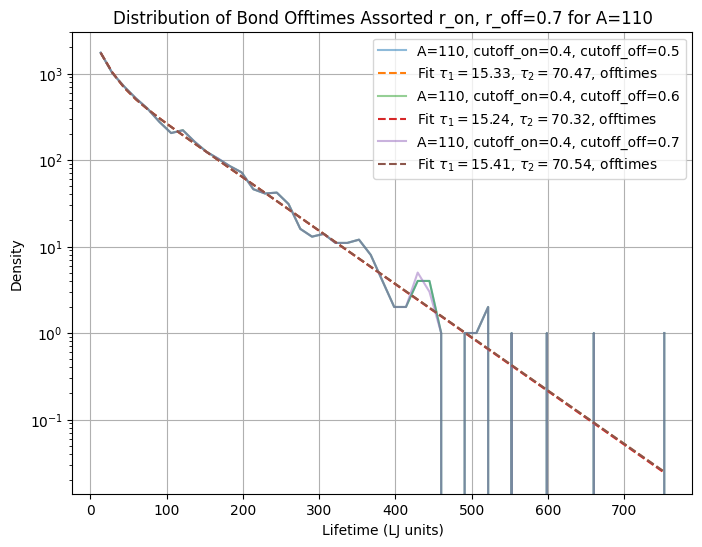

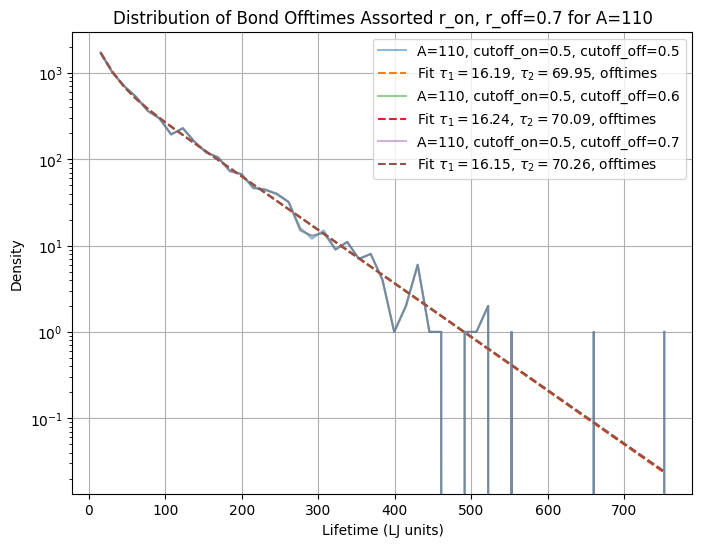

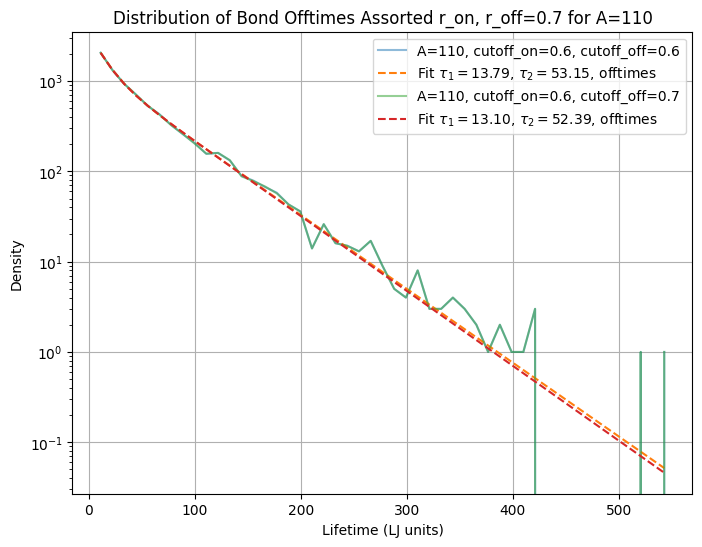

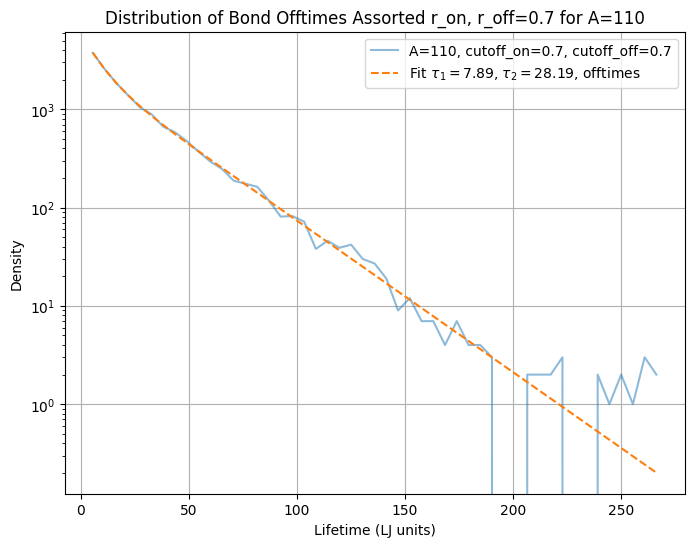

/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


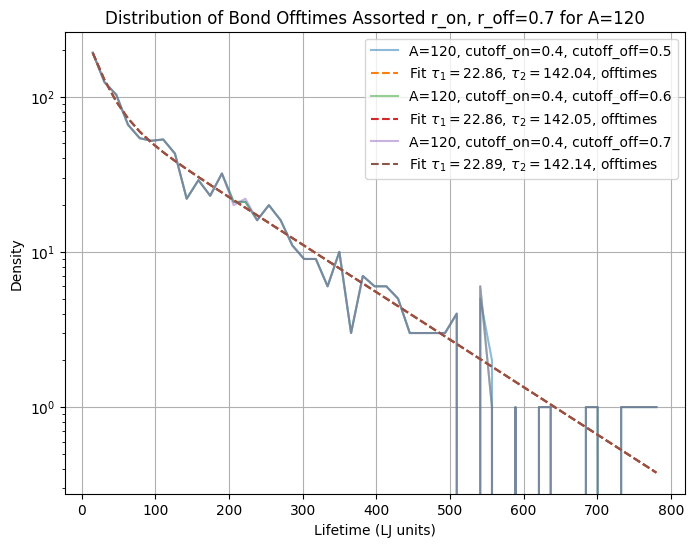

/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


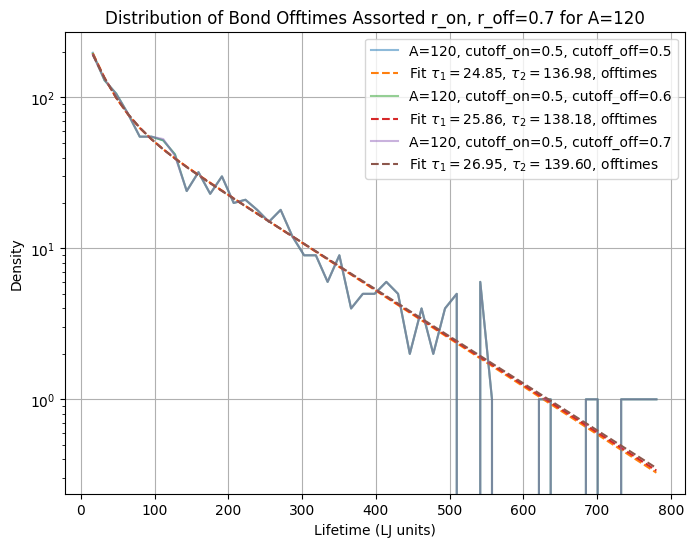

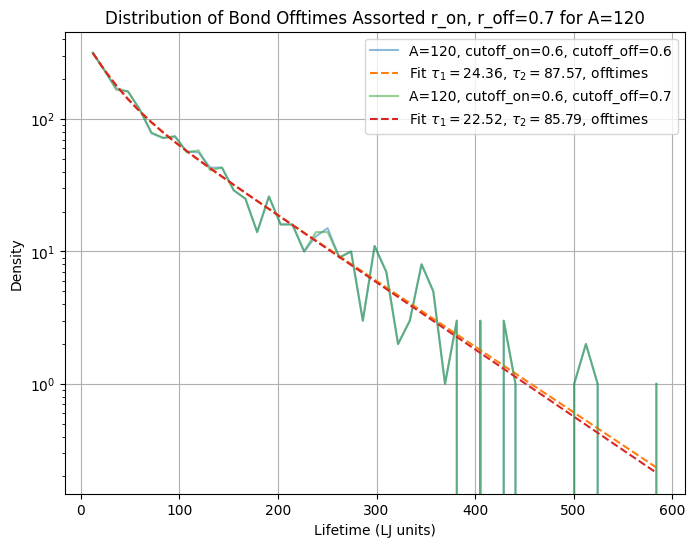

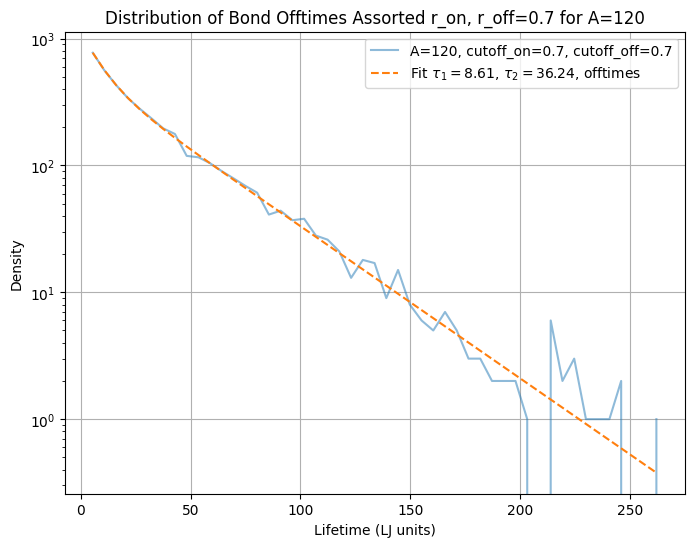

/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


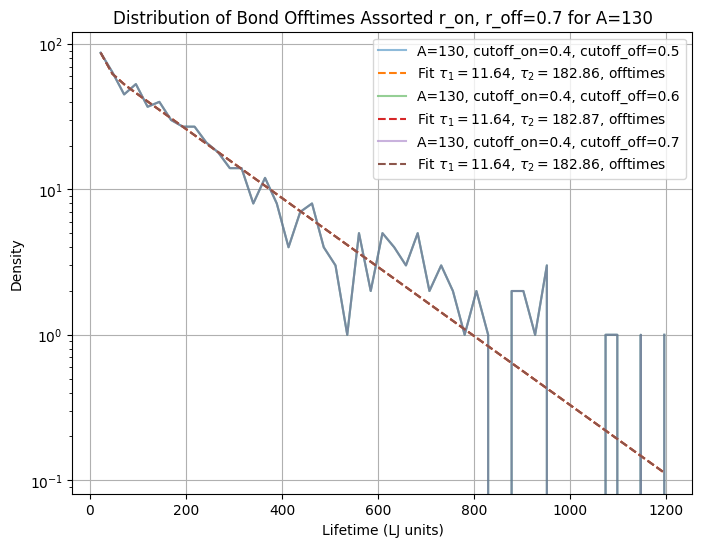

/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_431235/2229565480.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


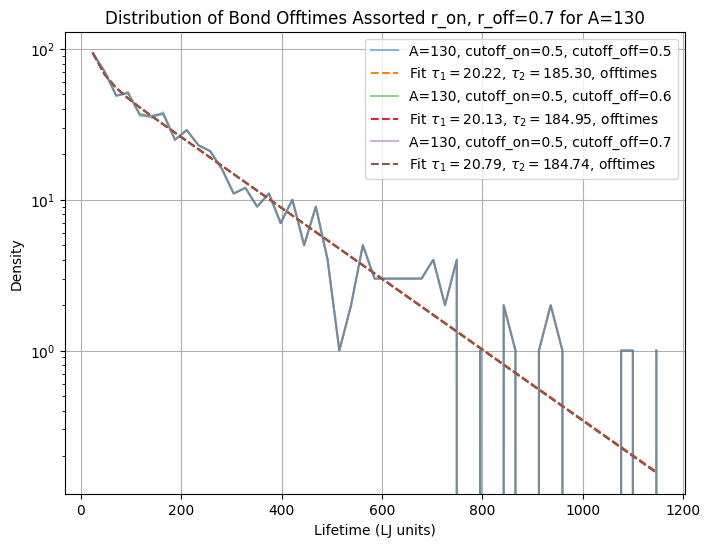

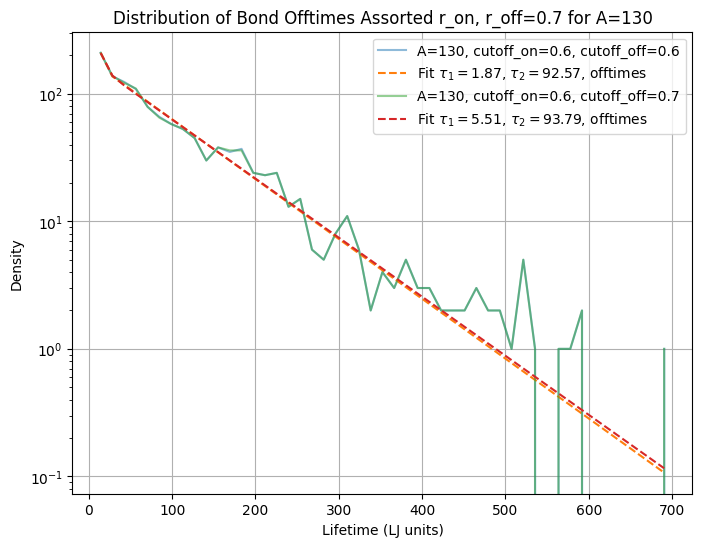

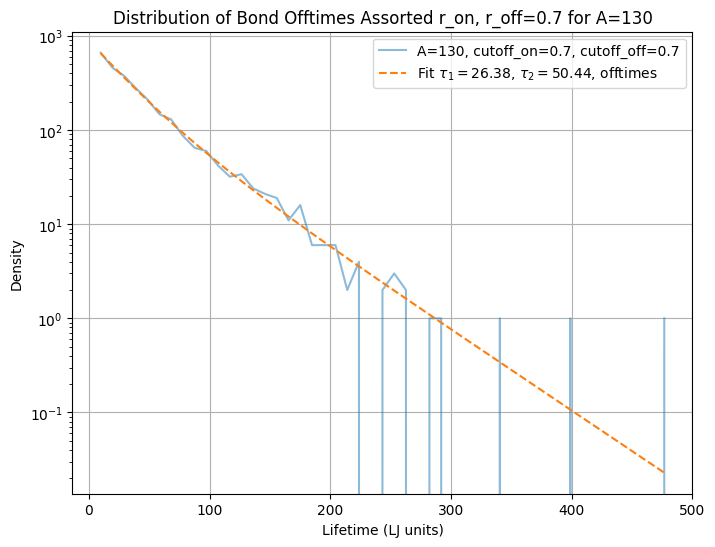

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def biexponential(x, a1, b1, a2, b2):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)

def single_exponential(x, a, b):
    return a * np.exp(-b * x)

tau_list = []

As = [80, 90, 100, 110, 120, 130]
cutoff_on_list = [0.4, 0.5, 0.6, 0.7]
cutoff_off_list = [0.5, 0.6, 0.7]

for A in As:
    for cutoff_on in cutoff_on_list:
        fig = plt.figure(figsize=(8, 6))
        for cutoff_off in cutoff_off_list:
            if cutoff_on <= cutoff_off:
            
                df = pd.read_csv(f"data/offtimes/buffered_offtimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                offtimes = np.array(df["offtime"].values)

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(offtimes, bins=50)
                # print(f"Processed offtimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(offtimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                # print(f"Removing, remaining offtimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=100000000)
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                # print(f"Fitted offtimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                tau_list.append([A, "off", cutoff_on, cutoff_off, tau_1, tau_2])

                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}, offtimes")

        plt.xlabel("Lifetime (LJ units)")
        plt.ylabel("Density")
        plt.yscale("log")
        # plt.ylim(0, 0.2)
        plt.grid()
        plt.title(f"Distribution of Bond Offtimes Assorted r_on, r_off={cutoff_off} for A={A}")
        plt.legend()
        plt.show()


df = pd.DataFrame(tau_list, columns=["A", "off/life", "cutoff_on", "cutoff_off", "tau_1", "tau_2"])
df.to_csv("data/offtimes/tau_offtimes.csv", index=False)




In [ ]:
life_tau_df = pd.read_csv("data/lifetimes/tau_lifetimes.csv")
off_tau_df = pd.read_csv("data/offtimes/tau_offtimes.csv")

# plot tau_2 for life over tau_2 for off for each A, cutoff_on, cutoff_off
plt.figure(figsize=(8, 6))
As = [80, 110]
cutoff_on_list = [0.4, 0.5, 0.6, 0.7]
cutoff_off_list = [0.5, 0.6, 0.7]

for A in As:
    for cutoff_off in cutoff_off_list:
        tau_life_over_off_list = []
        saved_cutoff_on_list = []
        for cutoff_on in cutoff_on_list:
            if cutoff_on <= cutoff_off:
                tau_life = life_tau_df.loc[(life_tau_df["A"] == A) & (life_tau_df["off/life"] == "life") & (life_tau_df["cutoff_on"] == cutoff_on) & (life_tau_df["cutoff_off"] == cutoff_off), "tau_2"].values[0]
                tau_off = off_tau_df.loc[(off_tau_df["A"] == A) & (off_tau_df["off/life"] == "off") & (off_tau_df["cutoff_on"] == cutoff_on) & (off_tau_df["cutoff_off"] == cutoff_off), "tau_2"].values[0]
                tau_life_over_off_list.append(tau_life / tau_off)
                print(tau_life_over_off_list)
                saved_cutoff_on_list.append(cutoff_on)

        plt.plot(saved_cutoff_on_list, np.array(tau_life_over_off_list), label=f"A={A}, cutoff_on={cutoff_on}", alpha=0.7)
        plt.xlabel(r"$r_{\text{on}}$ for (LJ distance units)")
        plt.ylabel(r"$\tau_{life}/\tau_{off}$ (LJ time units)")
        plt.title(f"Comparison of \\alpha/\\beta for Bond Lifetimes and Offtimes, cutoff_off={cutoff_off}")
        # plt.xscale("log")
        # plt.yscale("log")
        plt.grid()
        plt.legend()
        plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 800x600 with 0 Axes>